# Data Cleaning and Feature Engineering

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style= "darkgrid", color_codes = True)
import warnings
warnings.filterwarnings('ignore')

In [46]:
train_data = pd.read_csv('../data/tickets_data.csv', parse_dates=['Created','DepartureTime','CancelTime'],encoding='utf-8')
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101017 entries, 0 to 101016
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Created               101017 non-null  datetime64[ns]
 1   CancelTime            15326 non-null   datetime64[ns]
 2   DepartureTime         101017 non-null  datetime64[ns]
 3   BillID                101017 non-null  int64         
 4   TicketID              101017 non-null  float64       
 5   ReserveStatus         101017 non-null  int64         
 6   UserID                42543 non-null   float64       
 7   Male                  101017 non-null  bool          
 8   Price                 101017 non-null  float64       
 9   CouponDiscount        101017 non-null  float64       
 10  From                  101017 non-null  object        
 11  To                    101017 non-null  object        
 12  Domestic              101017 non-null  int64         
 13 

In [ ]:
# delete duplicated rows in dataset
def duplicated_rows(df):
    df=df.drop_duplicates(keep='first')
    return df

train_data= duplicated_rows(train_data)

In [48]:
#delete effectless_cols

def Del_Effectless_Cols(data):
    for col in ['UserID','NationalCode','BuyerMobile','HashEmail','CancelTime','HashPassportNumber_p','VehicleType','VehicleClass']: 
        data = data.drop(labels=col, inplace=False, axis=1)
    return data
        
train_data = Del_Effectless_Cols(train_data)

In [49]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101015 entries, 0 to 101016
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Created         101015 non-null  datetime64[ns]
 1   DepartureTime   101015 non-null  datetime64[ns]
 2   BillID          101015 non-null  int64         
 3   TicketID        101015 non-null  float64       
 4   ReserveStatus   101015 non-null  int64         
 5   Male            101015 non-null  bool          
 6   Price           101015 non-null  float64       
 7   CouponDiscount  101015 non-null  float64       
 8   From            101015 non-null  object        
 9   To              101015 non-null  object        
 10  Domestic        101015 non-null  int64         
 11  TripReason      101015 non-null  object        
 12  Vehicle         101015 non-null  object        
 13  Cancel          101015 non-null  int64         
dtypes: bool(1), datetime64[ns](2), float64(3)

In [50]:
# split dataset to train and validation
y=train_data.Cancel
x=train_data.drop(columns='Cancel')

x_train ,x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=24) 

In [51]:
# manag outlier in CouponDiscount
x_train.CouponDiscount.describe()
x_train.loc[((x_train.CouponDiscount <0) | (x_train.CouponDiscount == max(x_train.CouponDiscount))) , 'CouponDiscount']= 0

In [52]:
# Combine 'From' and 'To' columns to create a list of all cities
all_cities = train_data['From'].tolist() + train_data['To'].tolist()

# Create a set of unique cities and convert it back to a list
unique_cities = list(set(all_cities))

# Create a LabelEncoder instance
city_encoder = LabelEncoder()

# Fit the encoder on the unique cities
city_encoder.fit(unique_cities)

# Transform the 'From' and 'To' columns in the training data
x_train['From_encoded'] = city_encoder.transform(x_train['From'])
x_train['To_encoded'] = city_encoder.transform(x_train['To'])

# Fill missing values with -1
x_train['From_encoded'].fillna(-1, inplace=True)
x_train['To_encoded'].fillna(-1, inplace=True)

# Transform the 'From' and 'To' columns in the validation data
x_val['From_encoded'] = city_encoder.transform(x_val['From'])
x_val['To_encoded'] = city_encoder.transform(x_val['To'])

# Fill missing values with -1
x_val['From_encoded'].fillna(-1, inplace=True)
x_val['To_encoded'].fillna(-1, inplace=True)

#delete cols
x_train = x_train.drop(labels=['From','To'], axis=1)
x_val = x_val.drop(labels=['From','To'], axis=1)


In [53]:
def label_encode_boolean_column(df, column_name):
    df.loc[df[column_name] == True, column_name] = 1
    df.loc[df[column_name] == False, column_name] = 0
    df[column_name] = df[column_name].astype(int)
    return df

x_train = label_encode_boolean_column(x_train, 'Male')
x_val = label_encode_boolean_column(x_val, 'Male')


In [54]:
# encoding Vehicle & TripReason
def encode_col(df, col):
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    return df
    
x_train= encode_col(x_train, 'Vehicle') 
x_val= encode_col(x_val, 'Vehicle') 
x_train= encode_col(x_train, 'TripReason') 
x_val= encode_col(x_val, 'TripReason') 


In [55]:
def calculate_days_difference(df):
    df['Days_Difference'] = (df['DepartureTime'] - df['Created']).dt.days
    df.drop(columns=['DepartureTime','Created'], inplace=True, axis=1)
    return df

x_train = calculate_days_difference(x_train)
x_val = calculate_days_difference(x_val)

In [56]:
def add_family_member_feature(df):

    grouped_data = df.groupby('BillID')['Male'].nunique().reset_index()
    grouped_data = grouped_data.rename(columns={'Male': 'Family_Members'})
    df = pd.merge(df, grouped_data, on='BillID', how='left')
    
    return df

x_train = add_family_member_feature(x_train)
x_val = add_family_member_feature(x_val)

In [57]:
def count_tickets_per_order(df):
    # Group data by "BillId" and count the number of distinct values in "TicketId" column
    ticket_counts = df.groupby('BillID')['TicketID'].nunique().reset_index()
    # Rename the column
    ticket_counts = ticket_counts.rename(columns={'TicketID': 'Ticket_Count'})
    # Merge the ticket counts with the original data
    df = pd.merge(df, ticket_counts, on='BillID', how='left')
    
    return df

x_train = count_tickets_per_order(x_train)
x_val = count_tickets_per_order(x_val)

In [58]:
# feature scaling
scaler=StandardScaler()
x_v=x_val.values
scaled_x=scaler.fit_transform(x_train)
scaled_v=scaler.transform(x_v)

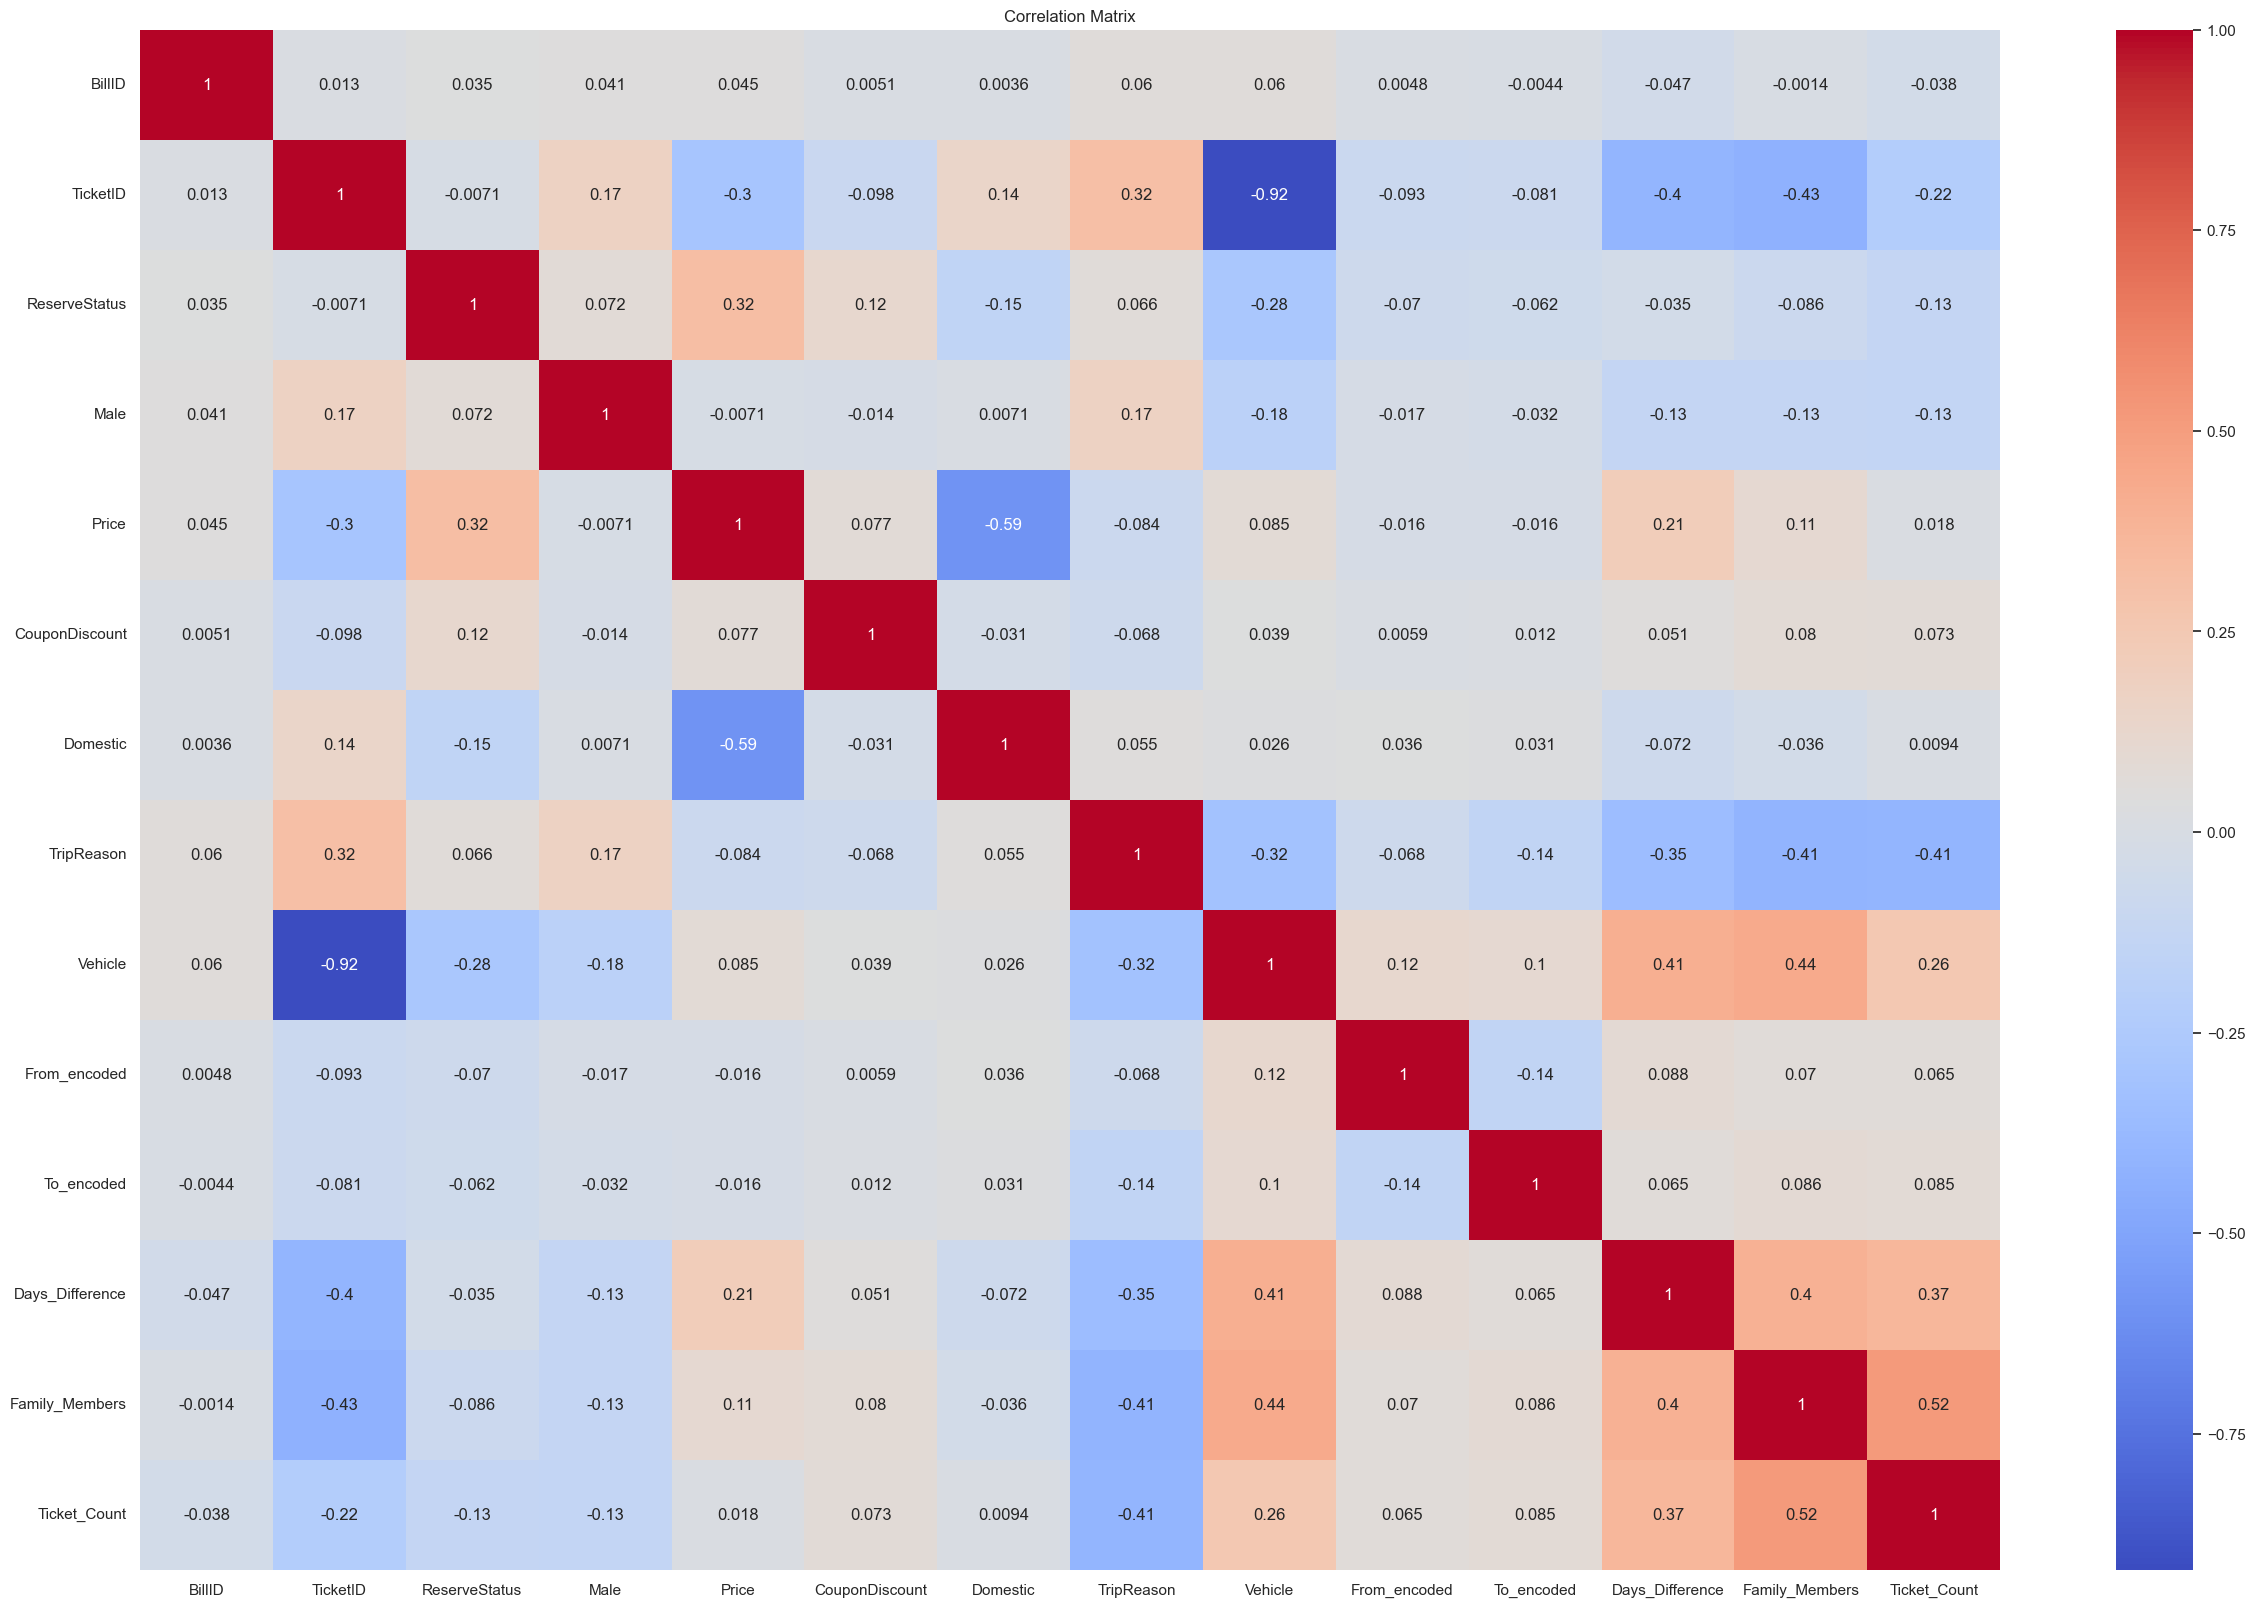

In [59]:
# Calculate the correlation matrix
corr_matrix =x_train.corr()
fig, ax = plt.subplots(figsize=(30, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

## Logistic Regression Models

Now we fit three logistic regression models for comparison:
1. **Null Model** - Intercept only (baseline)
2. **Basic Model** - Single predictor (Lead Time)
3. **Full Model** - All features with class weights

In [60]:
# Import statsmodels for GLM
import statsmodels.api as sm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, brier_score_loss,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.calibration import calibration_curve
from scipy import stats

In [61]:
# Prepare features for logistic regression
# Create feature matrix with scaled features
X_train_lr = x_train.copy()
X_test_lr = x_val.copy()

# Convert scaled arrays back to DataFrames with proper column names
feature_cols = x_train.columns.tolist()
X_train_scaled = pd.DataFrame(scaled_x, columns=feature_cols)
X_test_scaled = pd.DataFrame(scaled_v, columns=feature_cols)

print("Features for logistic regression:")
print(X_train_scaled.columns.tolist())
print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Features for logistic regression:
['BillID', 'TicketID', 'ReserveStatus', 'Male', 'Price', 'CouponDiscount', 'Domestic', 'TripReason', 'Vehicle', 'From_encoded', 'To_encoded', 'Days_Difference', 'Family_Members', 'Ticket_Count']

Training set shape: (80812, 14)
Test set shape: (20203, 14)


### Null Model (Intercept Only)

The null model predicts the same probability (global mean) for everyone.

In [62]:
# Null Model (Intercept Only)
print("="*60)
print("BASELINE MODEL: INTERCEPT ONLY (NULL MODEL)")
print("="*60)

# Reset indices to align data
y_train_reset = y_train.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)

# Fit null model (intercept only)
X_train_null = pd.DataFrame({'const': np.ones(len(y_train_reset))})
X_test_null = pd.DataFrame({'const': np.ones(len(y_val_reset))})

null_model = sm.GLM(y_train_reset, X_train_null, family=sm.families.Binomial()).fit()

print(null_model.summary())

# Predictions
y_pred_prob_null = null_model.predict(X_test_null)
y_pred_null = (y_pred_prob_null >= 0.5).astype(int)

print(f"\nNull Model Test Metrics:")
print(f"Predicted probability for all: {y_pred_prob_null.iloc[0]:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val_reset, y_pred_prob_null):.4f}")
print(f"Brier Score: {brier_score_loss(y_val_reset, y_pred_prob_null):.4f}")

BASELINE MODEL: INTERCEPT ONLY (NULL MODEL)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                80812
Model:                            GLM   Df Residuals:                    80811
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34454.
Date:                Thu, 29 Jan 2026   Deviance:                       68908.
Time:                        14:12:36   Pearson chi2:                 8.08e+04
No. Iterations:                     4   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const   

### Basic Model (Single Feature - Days_Difference)

Test if lead time alone has predictive power.

In [63]:
# Basic Model - Days_Difference Only
print("="*60)
print("BASIC MODEL: Days_Difference Only")
print("="*60)

X_train_basic = sm.add_constant(X_train_scaled[['Days_Difference']])
X_test_basic = sm.add_constant(X_test_scaled[['Days_Difference']])

basic_model = sm.GLM(y_train_reset, X_train_basic, family=sm.families.Binomial()).fit()

print(basic_model.summary())

# Predictions
y_pred_prob_basic = basic_model.predict(X_test_basic)

print(f"\nBasic Model Test Metrics:")
print(f"ROC-AUC: {roc_auc_score(y_val_reset, y_pred_prob_basic):.4f}")
print(f"Brier Score: {brier_score_loss(y_val_reset, y_pred_prob_basic):.4f}")

# Likelihood Ratio Test vs Null
lr_stat = 2 * (basic_model.llf - null_model.llf)
lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=1)
print(f"\nLikelihood Ratio Test vs Null:")
print(f"LR Statistic: {lr_stat:.2f}, p-value: {lr_pvalue:.4e}")

BASIC MODEL: Days_Difference Only
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                80812
Model:                            GLM   Df Residuals:                    80810
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34062.
Date:                Thu, 29 Jan 2026   Deviance:                       68125.
Time:                        14:13:00   Pearson chi2:                 8.03e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.009643
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const   

### Full Model (All Features with Class Weights)

Fit with all features using class weights to handle imbalance.

In [64]:
# Full Model with Class Weights
print("="*60)
print("FULL MODEL (All Features)")
print("="*60)

# Add constant to feature matrices
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Calculate class weights (inverse frequency)
n_samples = len(y_train_reset)
n_pos = y_train_reset.sum()
n_neg = n_samples - n_pos
weight_pos = n_samples / (2 * n_pos)
weight_neg = n_samples / (2 * n_neg)

# Create sample weights
sample_weights = np.where(y_train_reset == 1, weight_pos, weight_neg)

print(f"Class weights: Negative={weight_neg:.3f}, Positive={weight_pos:.3f}")

# Fit weighted logistic regression
full_model = sm.GLM(
    y_train_reset, 
    X_train_const, 
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(full_model.summary())

FULL MODEL (All Features)
Class weights: Negative=0.590, Positive=3.287
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancel   No. Observations:                80812
Model:                            GLM   Df Residuals:                 80797.00
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9281.1
Date:                Thu, 29 Jan 2026   Deviance:                       18562.
Time:                        14:13:30   Pearson chi2:                 8.06e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6854
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

### Model Evaluation and Comparison

In [65]:
# Model Evaluation
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions from full model
y_pred_prob_full = full_model.predict(X_test_const)

# Find optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_val_reset, y_pred_prob_full)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

# Predictions with optimal threshold
y_pred_optimal = (y_pred_prob_full >= optimal_threshold).astype(int)
y_pred_05 = (y_pred_prob_full >= 0.5).astype(int)

# Comparison of metrics
print("\n" + "="*60)
print("COMPARISON: Threshold=0.5 vs Optimal")
print("="*60)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_05 = [
    accuracy_score(y_val_reset, y_pred_05),
    precision_score(y_val_reset, y_pred_05),
    recall_score(y_val_reset, y_pred_05),
    f1_score(y_val_reset, y_pred_05),
    roc_auc_score(y_val_reset, y_pred_prob_full)
]
results_opt = [
    accuracy_score(y_val_reset, y_pred_optimal),
    precision_score(y_val_reset, y_pred_optimal),
    recall_score(y_val_reset, y_pred_optimal),
    f1_score(y_val_reset, y_pred_optimal),
    roc_auc_score(y_val_reset, y_pred_prob_full)
]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Threshold=0.5': results_05,
    f'Threshold={optimal_threshold:.3f}': results_opt
})
print(comparison_df.to_string(index=False))

# Confusion Matrix
print("\nConfusion Matrix (Optimal Threshold):")
cm = confusion_matrix(y_val_reset, y_pred_optimal)
print(cm)
print("\nClassification Report:")
print(classification_report(y_val_reset, y_pred_optimal, target_names=['No Cancel', 'Cancel']))

MODEL EVALUATION
Optimal threshold (Youden's J): 0.7509

COMPARISON: Threshold=0.5 vs Optimal
   Metric  Threshold=0.5  Threshold=0.751
 Accuracy       0.919517         0.973370
Precision       0.656867         0.915441
   Recall       0.967923         0.905754
 F1-Score       0.782620         0.910572
  ROC-AUC       0.992768         0.992768

Confusion Matrix (Optimal Threshold):
[[16926   253]
 [  285  2739]]

Classification Report:
              precision    recall  f1-score   support

   No Cancel       0.98      0.99      0.98     17179
      Cancel       0.92      0.91      0.91      3024

    accuracy                           0.97     20203
   macro avg       0.95      0.95      0.95     20203
weighted avg       0.97      0.97      0.97     20203



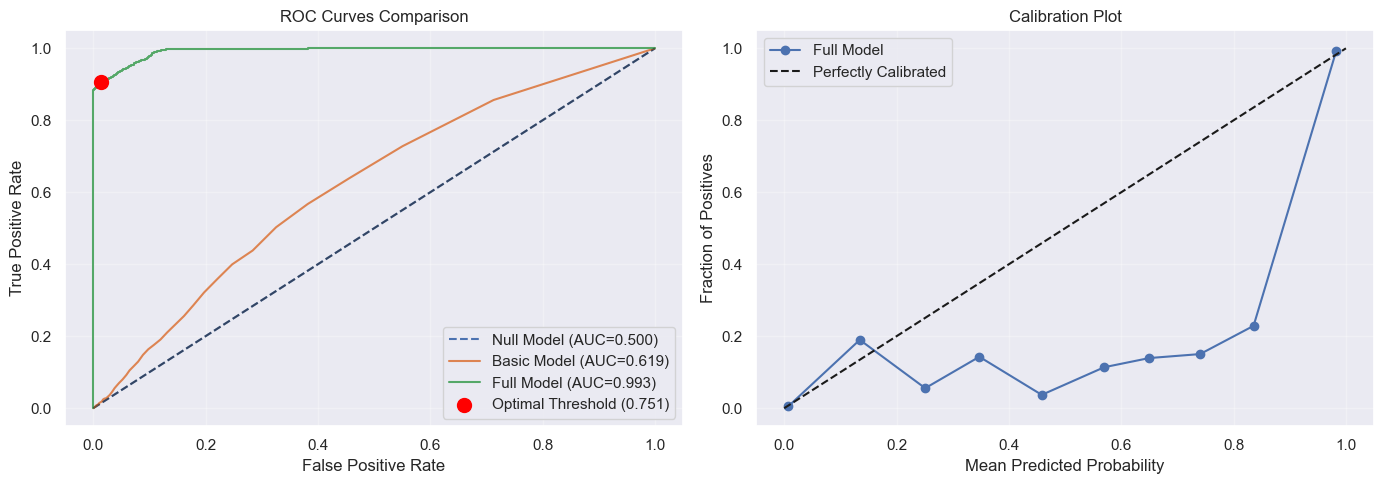

In [66]:
# ROC Curve Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
fpr_null, tpr_null, _ = roc_curve(y_val_reset, y_pred_prob_null)
fpr_basic, tpr_basic, _ = roc_curve(y_val_reset, y_pred_prob_basic)
fpr_full, tpr_full, _ = roc_curve(y_val_reset, y_pred_prob_full)

ax1.plot(fpr_null, tpr_null, label=f'Null Model (AUC={roc_auc_score(y_val_reset, y_pred_prob_null):.3f})', linestyle='--')
ax1.plot(fpr_basic, tpr_basic, label=f'Basic Model (AUC={roc_auc_score(y_val_reset, y_pred_prob_basic):.3f})')
ax1.plot(fpr_full, tpr_full, label=f'Full Model (AUC={roc_auc_score(y_val_reset, y_pred_prob_full):.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.scatter([fpr[optimal_idx]], [tpr[optimal_idx]], marker='o', s=100, c='red', 
            label=f'Optimal Threshold ({optimal_threshold:.3f})', zorder=5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves Comparison')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Calibration Plot
ax2 = axes[1]
prob_true, prob_pred = calibration_curve(y_val_reset, y_pred_prob_full, n_bins=10)
ax2.plot(prob_pred, prob_true, marker='o', label='Full Model')
ax2.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax2.set_xlabel('Mean Predicted Probability')
ax2.set_ylabel('Fraction of Positives')
ax2.set_title('Calibration Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# Final Model Comparison Summary
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)

# Fit unweighted full model for fair AIC/BIC comparison
full_model_unweighted = sm.GLM(
    y_train_reset, 
    X_train_const, 
    family=sm.families.Binomial()
).fit()

y_pred_prob_full_unweighted = full_model_unweighted.predict(X_test_const)

summary_data = {
    'Model': ['Null', 'Basic (Days_Difference)', 'Full Model (unweighted)'],
    'AIC': [null_model.aic, basic_model.aic, full_model_unweighted.aic],
    'BIC': [null_model.bic, basic_model.bic, full_model_unweighted.bic],
    'Log-Likelihood': [null_model.llf, basic_model.llf, full_model_unweighted.llf],
    'ROC-AUC': [
        roc_auc_score(y_val_reset, y_pred_prob_null),
        roc_auc_score(y_val_reset, y_pred_prob_basic),
        roc_auc_score(y_val_reset, y_pred_prob_full_unweighted)
    ],
    'Brier Score': [
        brier_score_loss(y_val_reset, y_pred_prob_null),
        brier_score_loss(y_val_reset, y_pred_prob_basic),
        brier_score_loss(y_val_reset, y_pred_prob_full_unweighted)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("WEIGHTED MODEL RESULTS (for imbalanced data)")
print("="*60)
print(f"Full Model (weighted) ROC-AUC: {roc_auc_score(y_val_reset, y_pred_prob_full):.4f}")
print(f"Full Model (weighted) Recall: {recall_score(y_val_reset, y_pred_optimal):.4f}")
print(f"Full Model (weighted) F1-Score: {f1_score(y_val_reset, y_pred_optimal):.4f}")


FINAL MODEL COMPARISON SUMMARY
                  Model          AIC            BIC  Log-Likelihood  ROC-AUC  Brier Score
                   Null 68909.591097 -844247.072056   -34453.795549 0.500000     0.127282
Basic (Days_Difference) 68128.538008 -845018.825265   -34062.269004 0.618583     0.126237
Full Model (unweighted) 10750.923080 -902275.541743    -5360.461540 0.989250     0.016499

WEIGHTED MODEL RESULTS (for imbalanced data)
Full Model (weighted) ROC-AUC: 0.9928
Full Model (weighted) Recall: 0.9058
Full Model (weighted) F1-Score: 0.9106
